# AMR Trend Forecasting - Training Pipeline

## 📋 Overview
Complete training pipeline for antimicrobial resistance (AMR) forecasting using WHO GLASS data (2020-2023). Covers baseline models, gradient boosting, and deep learning approaches with temporal cross-validation.

**Data:** 5,909 observations across 44 countries (2021-2023, after removing 2020 with missing lags)  
**Target:** `ResistancePercentage` (antimicrobial resistance percentage)  
**Models:** Naive → Linear/Ridge → XGBoost/LightGBM → LSTM

### 🔧 Fixes Applied (v2)
1. Removed `Resistance_YoY_change` from features — it encodes the target directly (lag1 + YoY = target)
2. Step 1 trains on 2021 only (2020 dropped: no valid lag features); Step 2 re-trains on 2021+2022 combined
3. LSTM reshapes tabular features to (samples, 1, features) — same train/val/test split as XGBoost
4. Replaced MAPE with sMAPE (avoids division-by-zero on 0% resistance values)
5. Fixed `region_decoder` to use correct `LabelEncoder` API
6. Replaced `'-'` strings with `np.nan` in results table (keeps column dtype numeric)

## 📚 1. Import Libraries

In [2]:
# Core Data Science
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Baseline Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Time Series
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📊 2. Load Data

In [3]:
# Load CLEANED training dataset (no data leakage)
# AMR_Training_Dataset_Final.csv: 2021-2023 (2020 removed — no valid lag features)
df = pd.read_csv('AMR_Training_Dataset_Final.csv')

# Basic info
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Year'].min()} - {df['Year'].max()}")
print(f"Countries: {df['CountryTerritoryArea'].nunique()}")
print(f"Pathogens: {df['PathogenName'].nunique()}")
print(f"Antibiotics: {df['AntibioticName'].nunique()}")

# Verify lag features are correct
sample_2021 = df[df['Year'] == 2021].iloc[0]
sample_2022 = df[
    (df['Year'] == 2022) &
    (df['CountryTerritoryArea'] == sample_2021['CountryTerritoryArea']) &
    (df['PathogenName']         == sample_2021['PathogenName']) &
    (df['AntibioticName']       == sample_2021['AntibioticName'])
]

if len(sample_2022) > 0:
    print(f"\nVerification - 2022 lag1 should equal 2021 value:")
    print(f"  2021 Resistance:      {sample_2021['ResistancePercentage']:.2f}")
    print(f"  2022 Resistance_lag1: {sample_2022.iloc[0]['Resistance_lag1']:.2f}")
    match = abs(sample_2021['ResistancePercentage'] - sample_2022.iloc[0]['Resistance_lag1']) < 0.01
    print(f"  Match: {match}")

# Display first few rows
df.head()

Dataset shape: (5909, 19)
Date range: 2021 - 2023
Countries: 44
Pathogens: 8
Antibiotics: 24

Verification - 2022 lag1 should equal 2021 value:
  2021 Resistance:      11.67
  2022 Resistance_lag1: 11.67
  Match: True


,CountryTerritoryArea,Iso3,WHORegionName,Year,PathogenName,AntibioticName,AntibioticClass,InfectionType,ResistancePercentage,Resistant,InterpretableAST,Total_DID,IncomeGroup,Country_Observation_Count,High_Quality_Country,Resistance_lag1,DID_lag1,Resistance_YoY_change,Resistance_rolling2yr
0,Austria,AUT,European Region,2021,Acinetobacter spp.,Amikacin,Other,Bloodstream,11.666667,7,60,9.271684,High,137,0,8.695652,9.236142,2.971014,8.695652
1,Austria,AUT,European Region,2022,Acinetobacter spp.,Amikacin,Other,Bloodstream,0.000000,0,87,10.887413,High,137,0,11.666667,9.271684,-11.666667,11.666667
2,Austria,AUT,European Region,2023,Acinetobacter spp.,Amikacin,Other,Bloodstream,5.405405,4,74,11.742038,High,137,0,0.000000,10.887413,5.405405,0.000000
3,Austria,AUT,European Region,2021,Acinetobacter spp.,Gentamicin,Other,Bloodstream,12.000000,6,50,9.271684,High,137,0,8.771930,9.236142,3.228070,8.771930
4,Austria,AUT,European Region,2022,Acinetobacter spp.,Gentamicin,Other,Bloodstream,0.000000,0,54,10.887413,High,137,0,12.000000,9.271684,-12.000000,12.000000


## 🔧 3. Data Preprocessing

### 3.1 Define Target and Features

> **Fix #1:** `Resistance_YoY_change` has been removed from features.  
> It equals `ResistancePercentage − Resistance_lag1`, so together they  
> perfectly reconstruct the target — causing R²=1.0 on linear models.

In [4]:
# Target variable
TARGET = 'ResistancePercentage'

# FIX #1: Resistance_YoY_change REMOVED.
#   Why: YoY_change = ResistancePercentage - Resistance_lag1
#   Having both lag1 and YoY_change in features lets linear models do:
#     prediction = lag1 + YoY_change = target  (perfect leakage, R²=1.0)
# Also removed: Resistance_rolling2yr (identical to Resistance_lag1 in clean dataset)
FEATURES = [
    # Temporal
    'Year', 'Resistance_lag1',
    # Geographic
    'CountryTerritoryArea', 'WHORegionName', 'IncomeGroup',
    # Pathogen
    'PathogenName', 'AntibioticName', 'AntibioticClass', 'InfectionType',
    # Consumption
    'Total_DID', 'DID_lag1',
    # Data Quality
    'Country_Observation_Count', 'High_Quality_Country'
]

# Categorical features
CATEGORICAL_FEATURES = [
    'CountryTerritoryArea', 'WHORegionName', 'IncomeGroup',
    'PathogenName', 'AntibioticName', 'AntibioticClass', 'InfectionType'
]

# Numerical features
NUMERICAL_FEATURES = [
    'Year', 'Resistance_lag1',
    'Total_DID', 'DID_lag1', 'Country_Observation_Count'
]

# Leakage columns (DO NOT USE)
LEAKAGE_COLUMNS = ['Resistant', 'InterpretableAST']

print(f"Target: {TARGET}")
print(f"Total features: {len(FEATURES)}")
print(f"Categorical: {len(CATEGORICAL_FEATURES)}")
print(f"Numerical: {len(NUMERICAL_FEATURES)}")
print("\nNOTE: Resistance_YoY_change removed to prevent arithmetic leakage.")

Target: ResistancePercentage
Total features: 13
Categorical: 7
Numerical: 5

NOTE: Resistance_YoY_change removed to prevent arithmetic leakage.


### 3.2 Verify Clean Dataset

In [5]:
# The clean dataset already has properly computed lag features
print("Clean dataset verification:")
print(f"Shape: {df.shape}")
print(f"Year range: {df['Year'].min()} - {df['Year'].max()}")

# Check for missing values
missing = df[FEATURES + [TARGET]].isnull().sum()
print(f"\nMissing values:")
print(missing[missing > 0] if missing.sum() > 0 else "  None ✅")

# Verify lag features are not identical to target (no leakage)
lag_corr = df[['ResistancePercentage', 'Resistance_lag1']].corr().iloc[0, 1]
print(f"\nCorrelation (target vs lag1): {lag_corr:.3f}")
print(f"Expected: 0.7-0.9 (not 1.0!)")

if lag_corr > 0.95:
    print("\n⚠️ WARNING: Correlation too high - possible data leakage!")
else:
    print("\n✅ Lag features look good - no leakage detected")

# Verify YoY_change is NOT in features
if 'Resistance_YoY_change' not in FEATURES:
    print("✅ Resistance_YoY_change correctly excluded from features")
else:
    print("❌ WARNING: Resistance_YoY_change still in features - remove it!")

# Copy for processing
df_processed = df.copy()

Clean dataset verification:
Shape: (5909, 19)
Year range: 2021 - 2023

Missing values:
  None ✅

Correlation (target vs lag1): 0.894
Expected: 0.7-0.9 (not 1.0!)

✅ Lag features look good - no leakage detected
✅ Resistance_YoY_change correctly excluded from features


### 3.3 Create Temporal Train/Val/Test Splits (BEFORE encoding to prevent leakage)

> **Step 1 → Step 2 training strategy:** Step 1 trains on 2021 and validates on 2022 to  
> determine optimal early-stopping rounds. 2020 was intentionally dropped — it had no valid  
> `Resistance_lag1` (no prior year exists). Step 2 then re-trains on combined 2021+2022 data  
> with those fixed hyperparameters and evaluates on 2023.  
> In the paper, state: *"Final models were trained on 2021–2022 data with validation-guided  
> early stopping, then evaluated on held-out 2023 data."*

In [6]:
# IMPORTANT: Time-based split FIRST (before any encoding)
# Dataset covers 2021-2023 (2020 dropped: no prior year for lag features)
# Step 1: Train=2021 | Val=2022 | Test=2023  (determines early-stopping rounds)
# Step 2 re-trains on 2021+2022 combined with fixed hyperparams, evaluates on 2023

train_df = df_processed[df_processed['Year'] == 2021].copy()
val_df   = df_processed[df_processed['Year'] == 2022].copy()
test_df  = df_processed[df_processed['Year'] == 2023].copy()

print(f"Step 1 — Train samples (2021): {len(train_df)}")
print(f"Step 1 — Validation samples (2022): {len(val_df)}")
print(f"Test samples (2023): {len(test_df)}")
print(f"\n✅ Step 1 temporal split complete — Step 2 will combine 2021+2022 for final training.")

Step 1 — Train samples (2021): 1804
Step 1 — Validation samples (2022): 1980
Test samples (2023): 2125

✅ Step 1 temporal split complete — Step 2 will combine 2021+2022 for final training.


## 📊 Dataset Split Statistics
Sample sizes per temporal split and missing-value audit for the Methods section.

In [7]:
# === DATASET SPLIT SUMMARY (paper Table 1) ===
print('=' * 62)
print('DATASET SPLIT STATISTICS')
print('=' * 62)
print(f'  Step 1 Training   (Year 2021):     {len(train_df):,} observations')
print(f'  Step 1 Validation (Year 2022):     {len(val_df):,} observations')
print(f'  Step 2 Training   (Years 2021+22): {len(train_df) + len(val_df):,} observations')
print(f'  Test              (Year 2023):     {len(test_df):,} observations')
print(f'  Total:                             {len(df_processed):,} observations')
print()
print(f'  Unique countries:    {df_processed["CountryTerritoryArea"].nunique()}')
print(f'  Unique pathogens:    {df_processed["PathogenName"].nunique()}')
print(f'  Unique antibiotics:  {df_processed["AntibioticName"].nunique()}')
print(f'  WHO Regions:         {df_processed["WHORegionName"].nunique()}')
print()

# Missing-value table on original df (before imputation)
_total = len(df)
_miss = df[FEATURES + [TARGET]].isnull().sum()
_miss_pct = (_miss / _total * 100).round(2)
_report = pd.DataFrame({'Missing N': _miss, 'Missing %': _miss_pct})
_report = _report[_report['Missing N'] > 0]
if len(_report) == 0:
    print('  No missing values in feature/target columns before imputation.')
else:
    print('  Missing values before imputation:')
    print(_report.to_string())
print('\n  Imputation strategy: median per (PathogenName, AntibioticName) pair')
print('\n✅ Dataset statistics logged.')


DATASET SPLIT STATISTICS
  Step 1 Training   (Year 2021):     1,804 observations
  Step 1 Validation (Year 2022):     1,980 observations
  Step 2 Training   (Years 2021+22): 3,784 observations
  Test              (Year 2023):     2,125 observations
  Total:                             5,909 observations

  Unique countries:    44
  Unique pathogens:    8
  Unique antibiotics:  24
  WHO Regions:         5

  No missing values in feature/target columns before imputation.

  Imputation strategy: median per (PathogenName, AntibioticName) pair

✅ Dataset statistics logged.


### 3.4 Encode Categorical Variables (using training data only)

In [8]:
# High cardinality features (use Target Encoding — smoothed mean from training data)
HIGH_CARDINALITY = ['CountryTerritoryArea', 'AntibioticName']

# Low cardinality features (use Label Encoding)
LOW_CARDINALITY = ['WHORegionName', 'IncomeGroup', 'PathogenName',
                   'AntibioticClass', 'InfectionType']

# Target encode using ONLY training data (prevents leakage)
print("Applying target encoding (computed from training data only)...")

for col in HIGH_CARDINALITY:
    global_mean    = train_df[TARGET].mean()
    category_stats = train_df.groupby(col)[TARGET].agg(['mean', 'count'])

    # Smoothing: pull small-sample categories toward global mean
    min_samples = 5
    category_stats['smoothed'] = (
        category_stats['mean'] * category_stats['count'] +
        global_mean * min_samples
    ) / (category_stats['count'] + min_samples)

    # Apply to all splits using TRAINING statistics only
    train_df[col + '_te'] = train_df[col].map(category_stats['smoothed']).fillna(global_mean)
    val_df[col + '_te']   = val_df[col].map(category_stats['smoothed']).fillna(global_mean)
    test_df[col + '_te']  = test_df[col].map(category_stats['smoothed']).fillna(global_mean)

# Label encode (fit on full data for consistent integer mapping)
print("Applying label encoding...")
label_encoders = {col: LabelEncoder() for col in LOW_CARDINALITY}

for col in LOW_CARDINALITY:
    label_encoders[col].fit(df_processed[col].astype(str))
    train_df[col] = label_encoders[col].transform(train_df[col].astype(str))
    val_df[col]   = label_encoders[col].transform(val_df[col].astype(str))
    test_df[col]  = label_encoders[col].transform(test_df[col].astype(str))

# Encoded feature list (Resistance_YoY_change excluded)
FEATURES_ENCODED = [
    'Year', 'Resistance_lag1',
    'CountryTerritoryArea_te', 'WHORegionName', 'IncomeGroup',
    'PathogenName', 'AntibioticName_te', 'AntibioticClass', 'InfectionType',
    'Total_DID', 'DID_lag1',
    'Country_Observation_Count', 'High_Quality_Country'
]

print("\n✅ Encoding complete!")
print(f"Train features shape: {train_df[FEATURES_ENCODED].shape}")
print(f"Val features shape:   {val_df[FEATURES_ENCODED].shape}")
print(f"Test features shape:  {test_df[FEATURES_ENCODED].shape}")

Applying target encoding (computed from training data only)...
Applying label encoding...

✅ Encoding complete!
Train features shape: (1804, 13)
Val features shape:   (1980, 13)
Test features shape:  (2125, 13)


### 3.5 Prepare Feature Matrices and Scale

In [9]:
# Prepare feature matrices
X_train = train_df[FEATURES_ENCODED].copy()
y_train = train_df[TARGET]

X_val   = val_df[FEATURES_ENCODED].copy()
y_val   = val_df[TARGET]

X_test  = test_df[FEATURES_ENCODED].copy()
y_test  = test_df[TARGET]

# Numerical features to scale (includes target-encoded categorical cols)
NUMERICAL_FEATURES_ENCODED = [
    'Year', 'Resistance_lag1',
    'CountryTerritoryArea_te', 'AntibioticName_te',
    'Total_DID', 'DID_lag1', 'Country_Observation_Count'
]

# Scale numerical features — fit on TRAINING data only
scaler = StandardScaler()
X_train[NUMERICAL_FEATURES_ENCODED] = scaler.fit_transform(X_train[NUMERICAL_FEATURES_ENCODED])
X_val[NUMERICAL_FEATURES_ENCODED]   = scaler.transform(X_val[NUMERICAL_FEATURES_ENCODED])
X_test[NUMERICAL_FEATURES_ENCODED]  = scaler.transform(X_test[NUMERICAL_FEATURES_ENCODED])

print("✅ Scaling complete!")
print(f"\nTrain shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"\nFeature means (should be ~0): {X_train[NUMERICAL_FEATURES_ENCODED].mean().values[:3]}")
print(f"Feature stds  (should be ~1): {X_train[NUMERICAL_FEATURES_ENCODED].std().values[:3]}")

✅ Scaling complete!

Train shape: (1804, 13)
Val shape:   (1980, 13)
Test shape:  (2125, 13)

Feature means (should be ~0): [ 0.00000000e+00 -3.54483626e-17 -7.48354323e-17]
Feature stds  (should be ~1): [0.         1.00027728 1.00027728]


## 🎯 4. Baseline Models

### 4.1 Naive Forecast (Last Known Value)

> **Fix #4:** MAPE replaced with **sMAPE** throughout.  
> `MAPE = mean(|true-pred| / true)` explodes when `true=0%` (common in resistance data).  
> `sMAPE = mean(2|true-pred| / (|true|+|pred|))` handles zeros gracefully.

In [10]:
def naive_forecast(y_train, y_val):
    """Predict using last training value (simple baseline)."""
    last_value  = y_train.iloc[-1]
    predictions = np.full(len(y_val), last_value)
    return predictions

# Make predictions
y_pred_naive = naive_forecast(y_train, y_val)

# Evaluate — use sMAPE, not MAPE (avoids division by zero for 0% resistance)
mae_naive  = mean_absolute_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_val, y_pred_naive))
smape_naive = np.mean(
    2 * np.abs(y_val - y_pred_naive) / (np.abs(y_val) + np.abs(y_pred_naive) + 1e-8)
) * 100

print("Naive Forecast Results:")
print(f"  MAE:   {mae_naive:.2f}%")
print(f"  RMSE:  {rmse_naive:.2f}%")
print(f"  sMAPE: {smape_naive:.2f}%")

Naive Forecast Results:
  MAE:   41.83%
  RMSE:  48.15%
  sMAPE: 103.23%


### 4.2 Linear Regression

In [11]:
# Evaluation function — uses sMAPE (symmetric MAPE, handles 0% resistance)
def evaluate_model(y_true, y_pred, model_name):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Results:")
    print(f"  MAE:   {mae:.2f}%")
    print(f"  RMSE:  {rmse:.2f}%")
    print(f"  sMAPE: {smape:.2f}%")
    print(f"  R²:    {r2:.3f}")

    return {'mae': mae, 'rmse': rmse, 'smape': smape, 'r2': r2}


# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_val_pred_lr  = lr_model.predict(X_val)
y_test_pred_lr = lr_model.predict(X_test)

# Evaluation
lr_results      = evaluate_model(y_val,  y_val_pred_lr,  "Linear Regression (Validation)")
lr_test_results = evaluate_model(y_test, y_test_pred_lr, "Linear Regression (Test)")

# Feature importance via coefficients
feature_importance = pd.DataFrame({
    'Feature':     FEATURES_ENCODED,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))


Linear Regression (Validation) Results:
  MAE:   8.64%
  RMSE:  12.92%
  sMAPE: 64.50%
  R²:    0.796

Linear Regression (Test) Results:
  MAE:   8.23%
  RMSE:  11.96%
  sMAPE: 63.56%
  R²:    0.821

Top 10 Features:
                    Feature  Coefficient
1           Resistance_lag1    23.088387
2   CountryTerritoryArea_te     4.274662
10                 DID_lag1    -2.653703
8             InfectionType    -2.543035
6         AntibioticName_te     2.171617
9                 Total_DID     2.143646
12     High_Quality_Country     1.707700
5              PathogenName    -0.702194
4               IncomeGroup     0.281492
7           AntibioticClass    -0.168914


### 4.3 Ridge Regression (with Regularization)

In [12]:
from sklearn.linear_model import RidgeCV

# Find best alpha with cross-validation
alphas      = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_model = RidgeCV(alphas=alphas, cv=5)
ridge_model.fit(X_train, y_train)

print(f"Best alpha: {ridge_model.alpha_}")

# Predictions
y_val_pred_ridge  = ridge_model.predict(X_val)
y_test_pred_ridge = ridge_model.predict(X_test)

# Evaluation
ridge_results      = evaluate_model(y_val,  y_val_pred_ridge,  "Ridge Regression (Validation)")
ridge_test_results = evaluate_model(y_test, y_test_pred_ridge, "Ridge Regression (Test)")

Best alpha: 10.0

Ridge Regression (Validation) Results:
  MAE:   8.64%
  RMSE:  12.90%
  sMAPE: 64.34%
  R²:    0.797

Ridge Regression (Test) Results:
  MAE:   8.25%
  RMSE:  11.95%
  sMAPE: 63.32%
  R²:    0.821


## 🌳 5. Gradient Boosting Models

### 5.1 XGBoost

[0]	validation_0-mae:25.07089
[100]	validation_0-mae:12.76270
[200]	validation_0-mae:8.82379
[300]	validation_0-mae:7.61123
[400]	validation_0-mae:7.21506
[499]	validation_0-mae:7.09271

XGBoost (Validation) Results:
  MAE:   7.09%
  RMSE:  11.62%
  sMAPE: 52.26%
  R²:    0.835

XGBoost (Test) Results:
  MAE:   7.07%
  RMSE:  10.80%
  sMAPE: 53.27%
  R²:    0.854

Top 10 Features:
                    Feature  Importance
1           Resistance_lag1    0.505483
2   CountryTerritoryArea_te    0.090224
6         AntibioticName_te    0.067378
5              PathogenName    0.059761
8             InfectionType    0.052838
4               IncomeGroup    0.050563
7           AntibioticClass    0.043583
3             WHORegionName    0.041319
9                 Total_DID    0.026775
10                 DID_lag1    0.021119


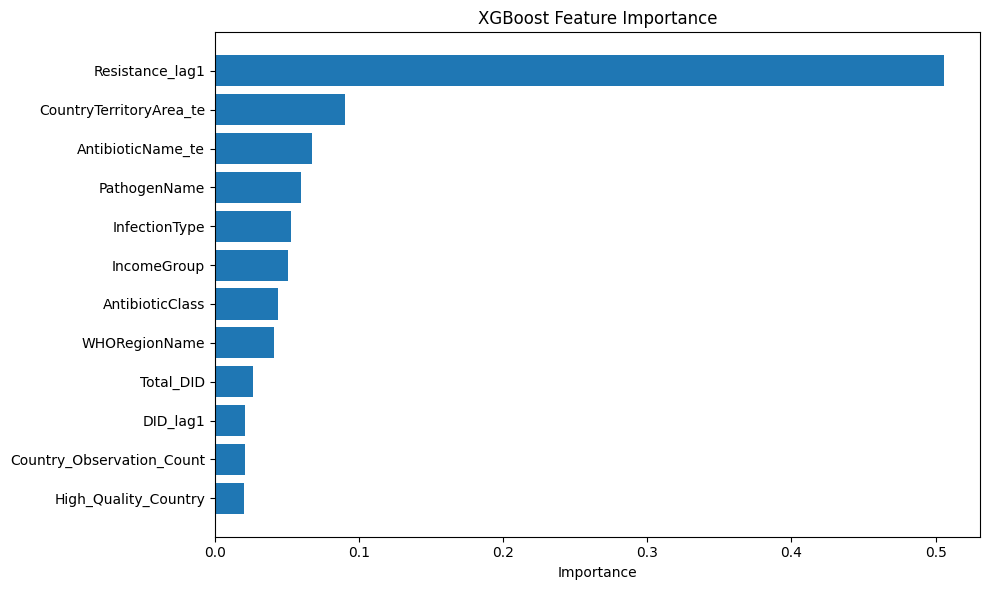

In [13]:
# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# Predictions
y_val_pred_xgb  = xgb_model.predict(X_val)
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluation
xgb_results      = evaluate_model(y_val,  y_val_pred_xgb,  "XGBoost (Validation)")
xgb_test_results = evaluate_model(y_test, y_test_pred_xgb, "XGBoost (Test)")

# Feature importance
xgb_importance = pd.DataFrame({
    'Feature':    FEATURES_ENCODED,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(xgb_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(xgb_importance['Feature'][:12], xgb_importance['Importance'][:12])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=300)
plt.show()

## 🔍 5b. SHAP Interpretability Analysis

SHAP (SHapley Additive exPlanations) gives direction-aware, per-prediction feature importance for XGBoost. It is now the standard in biomedical ML papers because gain-based importance is known to be biased toward high-cardinality features.

In [14]:
# Install SHAP (skip if already present)
try:
    import shap
    print(f'✅ shap {shap.__version__} already installed')
except ImportError:
    import subprocess, sys as _sys
    subprocess.check_call([_sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
    print(f'✅ shap {shap.__version__} installed')


✅ shap 0.50.0 already installed


Computing SHAP values on test set (may take ~30 s)...
✅ SHAP values ready — shape: (2125, 13)


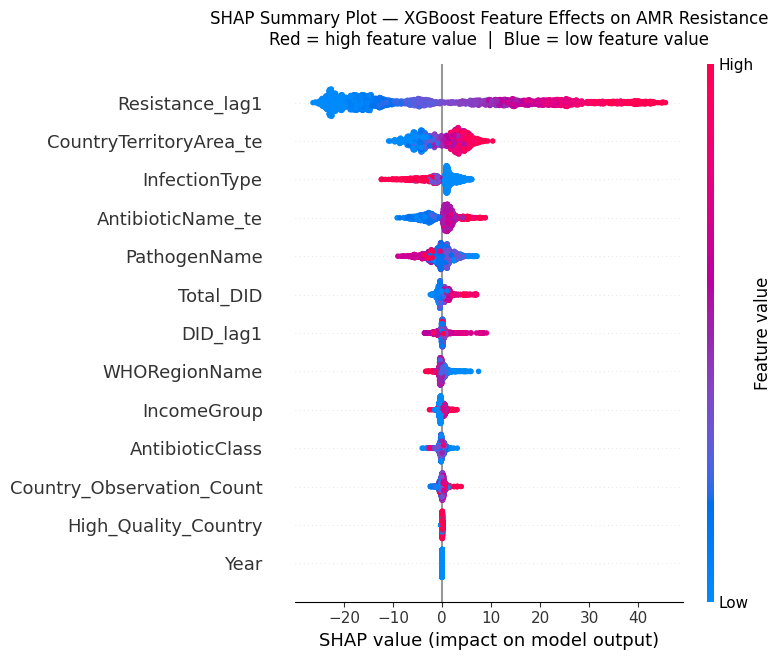

Saved: shap_summary_dot.png


In [15]:
# --- Compute SHAP values (TreeExplainer — exact & fast for XGBoost) ---
print('Computing SHAP values on test set (may take ~30 s)...')
shap_explainer = shap.TreeExplainer(xgb_model)
shap_values    = shap_explainer.shap_values(X_test[FEATURES_ENCODED])
print(f'✅ SHAP values ready — shape: {shap_values.shape}')

# --- Plot 1: Dot-cloud summary (direction + magnitude) ---
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test[FEATURES_ENCODED],
    feature_names=FEATURES_ENCODED,
    plot_type='dot',
    max_display=13,
    show=False
)
plt.title('SHAP Summary Plot — XGBoost Feature Effects on AMR Resistance\n'
          'Red = high feature value  |  Blue = low feature value', pad=14)
plt.tight_layout()
plt.savefig('shap_summary_dot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: shap_summary_dot.png')


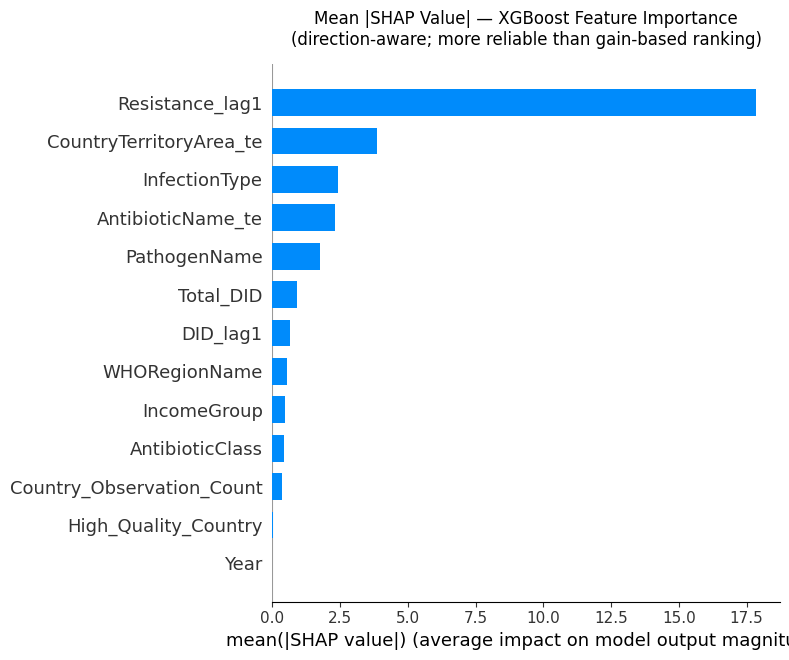

Saved: shap_bar.png


In [16]:
# --- Plot 2: Mean |SHAP| bar chart (less biased than gain importance) ---
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test[FEATURES_ENCODED],
    feature_names=FEATURES_ENCODED,
    plot_type='bar',
    max_display=13,
    show=False
)
plt.title('Mean |SHAP Value| — XGBoost Feature Importance\n'
          '(direction-aware; more reliable than gain-based ranking)', pad=14)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: shap_bar.png')


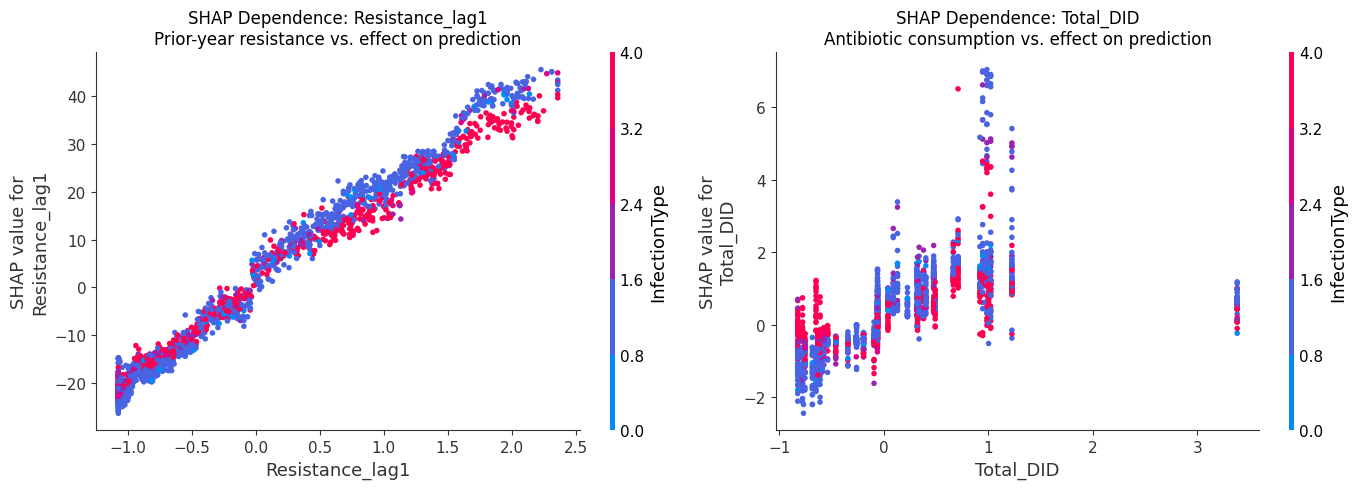

Saved: shap_dependence.png


In [17]:
# --- Plot 3: SHAP dependence plots for two top features ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top feature: Resistance_lag1
lag1_idx = list(FEATURES_ENCODED).index('Resistance_lag1')
shap.dependence_plot(
    lag1_idx,
    shap_values,
    X_test[FEATURES_ENCODED],
    feature_names=FEATURES_ENCODED,
    ax=axes[0],
    show=False
)
axes[0].set_title('SHAP Dependence: Resistance_lag1\n'
                  'Prior-year resistance vs. effect on prediction')

# Fifth feature: antibiotic consumption (Total_DID)
did_idx = list(FEATURES_ENCODED).index('Total_DID')
shap.dependence_plot(
    did_idx,
    shap_values,
    X_test[FEATURES_ENCODED],
    feature_names=FEATURES_ENCODED,
    ax=axes[1],
    show=False
)
axes[1].set_title('SHAP Dependence: Total_DID\n'
                  'Antibiotic consumption vs. effect on prediction')

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: shap_dependence.png')


### 5.2 LightGBM

In [18]:
# Train LightGBM
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_round=50,
    verbose=-1
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)]
)

# Predictions
y_val_pred_lgbm  = lgbm_model.predict(X_val)
y_test_pred_lgbm = lgbm_model.predict(X_test)

# Evaluation
lgbm_results      = evaluate_model(y_val,  y_val_pred_lgbm,  "LightGBM (Validation)")
lgbm_test_results = evaluate_model(y_test, y_test_pred_lgbm, "LightGBM (Test)")


LightGBM (Validation) Results:
  MAE:   7.23%
  RMSE:  11.81%
  sMAPE: 53.47%
  R²:    0.830

LightGBM (Test) Results:
  MAE:   7.17%
  RMSE:  10.84%
  sMAPE: 55.12%
  R²:    0.853


## 🧠 6. Deep Learning Models

### 6.1 Prepare Data for LSTM

> **LSTM data preparation:** Tabular features are reshaped to `(samples, 1, features)` — no  
> sequence creation needed. LSTM uses identical train/val/test splits as XGBoost for fair comparison.

In [19]:
# Use identical train/val/test data as XGBoost — fair comparison
# Reshape tabular features to (samples, 1, features) for LSTM
X_lstm_train = X_train.values.reshape(-1, 1, X_train.shape[1])
y_lstm_train = y_train.values

X_lstm_val = X_val.values.reshape(-1, 1, X_val.shape[1])
y_lstm_val = y_val.values

X_lstm_test = X_test.values.reshape(-1, 1, X_test.shape[1])
y_lstm_test = y_test.values

print(f"Train sequences: {X_lstm_train.shape}")
print(f"Val sequences:   {X_lstm_val.shape}")
print(f"Test sequences:  {X_lstm_test.shape}")
print("✅ LSTM uses same train/val/test split as all other models!")

Train sequences: (1804, 1, 13)
Val sequences:   (1980, 1, 13)
Test sequences:  (2125, 1, 13)
✅ LSTM uses same train/val/test split as all other models!


### 6.2 LSTM Model

In [20]:
class AMR_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(AMR_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]   # Take last timestep
        return self.fc(last_output)


# Check GPU availability with hardware probe
# torch.cuda.is_available() returns True even when the installed PyTorch build
# has no compiled kernel for the GPU architecture (e.g. RTX 5060 / sm_120).
# We run a tiny tensor op to confirm CUDA actually works before trusting it.

def _probe_cuda():
    """Return True only if CUDA is present AND a real op succeeds."""
    if not torch.cuda.is_available():
        return False
    try:
        _t = torch.tensor([1.0], device="cuda")
        _ = _t + _t
        del _t
        return True
    except RuntimeError:
        return False

device = torch.device("cuda" if _probe_cuda() else "cpu")
if device.type == "cuda":
    print(f"Using device: {device} — {torch.cuda.get_device_name(0)}")
else:
    print(f"Using device: {device}")

# Initialize model
input_size = X_lstm_train.shape[2]
lstm_model = AMR_LSTM(
    input_size=input_size, hidden_size=64, num_layers=2, dropout=0.3
).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

Using device: cuda — NVIDIA GeForce RTX 5060 Laptop GPU


In [21]:
# Prepare PyTorch data loaders
batch_size = 64

train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_lstm_train),
    torch.FloatTensor(y_lstm_train).unsqueeze(1)
)
val_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_lstm_val),
    torch.FloatTensor(y_lstm_val).unsqueeze(1)
)
test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_lstm_test),
    torch.FloatTensor(y_lstm_test).unsqueeze(1)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)

print("Data loaders created!")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

Data loaders created!
  Train batches: 29
  Val batches:   31
  Test batches:  34


In [22]:
# Training loop with early stopping
epochs          = 100
best_val_loss   = float('inf')
patience_counter = 0
patience        = 30

train_losses, val_losses = [], []

for epoch in range(epochs):
    # ── Training ────────────────────────────────
    lstm_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs  = lstm_model(X_batch)
        loss     = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validation ──────────────────────────────
    lstm_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs   = lstm_model(X_batch)
            val_loss += criterion(outputs, y_batch).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # ── Early stopping ──────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(lstm_model.state_dict(), 'best_lstm_model.pth')
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}]  Train: {train_loss:.4f}  Val: {val_loss:.4f}')

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

print("\nTraining complete!")

Epoch [10/100]  Train: 228.4197  Val: 183.7004
Epoch [20/100]  Train: 178.3842  Val: 155.1253
Epoch [30/100]  Train: 170.6778  Val: 151.3011
Epoch [40/100]  Train: 162.8998  Val: 150.2770
Epoch [50/100]  Train: 167.6549  Val: 151.4918
Epoch [60/100]  Train: 155.0373  Val: 152.0659
Epoch [70/100]  Train: 147.6975  Val: 151.9275
Early stopping at epoch 70

Training complete!


In [23]:
# Load best model and evaluate on test set
lstm_model.load_state_dict(torch.load('best_lstm_model.pth'))

lstm_model.eval()
y_pred_lstm, y_true_lstm = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = lstm_model(X_batch)
        y_pred_lstm.extend(outputs.cpu().numpy().flatten())
        y_true_lstm.extend(y_batch.cpu().numpy().flatten())

lstm_results = evaluate_model(
    np.array(y_true_lstm),
    np.array(y_pred_lstm),
    "LSTM (Test)"
)


LSTM (Test) Results:
  MAE:   7.32%
  RMSE:  10.97%
  sMAPE: 54.86%
  R²:    0.849


## 🔄 Step 2: Retrain on Combined 2021+2022 Data

Step 1 (train=2021, val=2022) determined optimal early-stopping rounds.
Step 2 re-trains on 2021+2022 combined with those fixed params,
then evaluates on 2023 test — standard validation-guided training.

In [24]:
train_val_df = df_processed[df_processed['Year'].isin([2021, 2022])].copy()

for col in HIGH_CARDINALITY:
    global_mean    = train_val_df[TARGET].mean()
    category_stats = train_val_df.groupby(col)[TARGET].agg(['mean', 'count'])
    min_samples = 5
    category_stats['smoothed'] = (
        category_stats['mean'] * category_stats['count'] +
        global_mean * min_samples
    ) / (category_stats['count'] + min_samples)
    train_val_df[col + '_te'] = train_val_df[col].map(category_stats['smoothed']).fillna(global_mean)
    test_df[col + '_te']      = test_df[col].map(category_stats['smoothed']).fillna(global_mean)

for col in LOW_CARDINALITY:
    train_val_df[col] = label_encoders[col].transform(train_val_df[col].astype(str))

X_tv = train_val_df[FEATURES_ENCODED].copy()
y_tv = train_val_df[TARGET]
X_te = test_df[FEATURES_ENCODED].copy()
y_te = test_df[TARGET]

scaler_2 = StandardScaler()
X_tv[NUMERICAL_FEATURES_ENCODED] = scaler_2.fit_transform(X_tv[NUMERICAL_FEATURES_ENCODED])
X_te[NUMERICAL_FEATURES_ENCODED] = scaler_2.transform(X_te[NUMERICAL_FEATURES_ENCODED])

print(f'Step 2 training: {X_tv.shape[0]} samples (2021+2022)')
print(f'Step 2 test:     {X_te.shape[0]} samples (2023)')

lr2 = LinearRegression().fit(X_tv, y_tv)
y2_lr = lr2.predict(X_te)
lr2_res = evaluate_model(y_te, y2_lr, 'Step 2 · Linear Regression (Test)')

ridge2 = Ridge(alpha=ridge_model.alpha_).fit(X_tv, y_tv)
y2_ridge = ridge2.predict(X_te)
ridge2_res = evaluate_model(y_te, y2_ridge, 'Step 2 · Ridge (Test)')

best_rounds = getattr(xgb_model, 'best_iteration', 499) + 1
xgb2 = XGBRegressor(
    n_estimators=best_rounds,
    learning_rate=0.01, max_depth=6, min_child_weight=1,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    eval_metric='mae'
).fit(X_tv, y_tv)
y2_xgb = xgb2.predict(X_te)
xgb2_res = evaluate_model(y_te, y2_xgb, 'Step 2 · XGBoost (Test)')

lgbm_best = getattr(lgbm_model, 'best_iteration', 499) + 1
lgbm2 = LGBMRegressor(
    n_estimators=lgbm_best,
    learning_rate=0.01, max_depth=6, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
).fit(X_tv, y_tv)
y2_lgbm = lgbm2.predict(X_te)
lgbm2_res = evaluate_model(y_te, y2_lgbm, 'Step 2 · LightGBM (Test)')

best_epoch = int(np.argmin(val_losses)) + 1
X_lstm_tv = X_tv.values.reshape(-1, 1, X_tv.shape[1])
y_lstm_tv = y_tv.values
X_lstm_te2 = X_te.values.reshape(-1, 1, X_te.shape[1])
y_lstm_te2 = y_te.values

lstm2 = AMR_LSTM(input_size=X_tv.shape[1], hidden_size=64, num_layers=2, dropout=0.3).to(device)
opt2 = torch.optim.Adam(lstm2.parameters(), lr=0.001, weight_decay=1e-5)

tv_ds = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_lstm_tv),
    torch.FloatTensor(y_lstm_tv).unsqueeze(1)
)
tv_loader = DataLoader(tv_ds, batch_size=64, shuffle=True)

lstm2.train()
for ep in range(best_epoch):
    for X_b, y_b in tv_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        opt2.zero_grad()
        loss = nn.MSELoss()(lstm2(X_b), y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm2.parameters(), max_norm=1.0)
        opt2.step()
    if (ep + 1) % 10 == 0:
        print(f'LSTM retrain epoch [{ep+1}/{best_epoch}]')

lstm2.eval()
y2_lstm = []
with torch.no_grad():
    for i in range(0, len(X_lstm_te2), 64):
        xb = torch.FloatTensor(X_lstm_te2[i:i+64]).to(device)
        y2_lstm.extend(lstm2(xb).cpu().numpy().flatten())
y2_lstm = np.array(y2_lstm)
lstm2_res = evaluate_model(y_lstm_te2, y2_lstm, 'Step 2 · LSTM (Test)')

y_test_pred_lr    = y2_lr
y_test_pred_ridge = y2_ridge
y_test_pred_xgb   = y2_xgb
y_test_pred_lgbm  = y2_lgbm
y_pred_lstm       = y2_lstm.tolist()
y_true_lstm       = y_lstm_te2.tolist()

lr_test_results    = lr2_res
ridge_test_results = ridge2_res
xgb_test_results   = xgb2_res
lgbm_test_results  = lgbm2_res
lstm_results       = lstm2_res

xgb_model = xgb2
X_test    = X_te
y_test    = y_te

print('\n✅ Step 2 complete — downstream cells now use combined-data results.')


Step 2 training: 3784 samples (2021+2022)
Step 2 test:     2125 samples (2023)

Step 2 · Linear Regression (Test) Results:
  MAE:   8.13%
  RMSE:  11.67%
  sMAPE: 61.67%
  R²:    0.830

Step 2 · Ridge (Test) Results:
  MAE:   8.15%
  RMSE:  11.67%
  sMAPE: 61.64%
  R²:    0.830

Step 2 · XGBoost (Test) Results:
  MAE:   6.13%
  RMSE:  9.57%
  sMAPE: 49.72%
  R²:    0.885

Step 2 · LightGBM (Test) Results:
  MAE:   6.30%
  RMSE:  9.76%
  sMAPE: 50.55%
  R²:    0.881
LSTM retrain epoch [10/40]
LSTM retrain epoch [20/40]
LSTM retrain epoch [30/40]
LSTM retrain epoch [40/40]

Step 2 · LSTM (Test) Results:
  MAE:   7.15%
  RMSE:  10.84%
  sMAPE: 54.05%
  R²:    0.853

✅ Step 2 complete — downstream cells now use combined-data results.


## 📐 Bootstrap Confidence Intervals

95% bootstrap CIs let us determine whether differences between models (e.g., XGBoost vs LightGBM) are statistically meaningful.

In [25]:
# ─── Bootstrap 95% CI for all models ────────────────────────────────────
y_pred_lstm_np = np.array(y_pred_lstm).flatten()
y_true_lstm_arr= np.array(y_true_lstm).flatten()  # Use exact ground truth from eval loop

def bootstrap_mae(y_true, y_pred, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    maes = np.empty(n_boot)
    for i in range(n_boot):
        idx     = rng.integers(0, n, size=n)
        maes[i] = np.mean(np.abs(y_true[idx] - y_pred[idx]))
    return np.percentile(maes, [2.5, 97.5])

# Point MAEs already computed; bootstrap CIs per model
models_for_ci = {
    'Naive':             (y_test.values, np.full(len(y_test), y_train.iloc[-1])),
    'Linear Regression': (y_test.values, y_test_pred_lr),
    'Ridge':             (y_test.values, y_test_pred_ridge),
    'XGBoost':           (y_test.values, y_test_pred_xgb),
    'LightGBM':          (y_test.values, y_test_pred_lgbm),
    'LSTM':              (y_true_lstm_arr,  y_pred_lstm_np),
}

ci_results = {}
for name, (yt, yp) in models_for_ci.items():
    lo, hi = bootstrap_mae(yt, yp)
    ci_results[name] = {'lo': lo, 'hi': hi, 'mae': np.mean(np.abs(yt - yp))}
    print(f'{name:20s}  MAE={ci_results[name]["mae"]:.2f}%  95% CI [{lo:.2f}, {hi:.2f}]')

import pandas as pd
ci_df = pd.DataFrame(ci_results).T.reset_index().rename(columns={'index': 'Model'})
ci_df.to_csv('model_mae_bootstrap_ci.csv', index=False)
print('\n✅ Saved: model_mae_bootstrap_ci.csv')


Naive                 MAE=41.79%  95% CI [40.77, 42.79]
Linear Regression     MAE=8.13%  95% CI [7.78, 8.49]
Ridge                 MAE=8.15%  95% CI [7.79, 8.50]
XGBoost               MAE=6.13%  95% CI [5.83, 6.44]
LightGBM              MAE=6.30%  95% CI [6.00, 6.63]
LSTM                  MAE=7.15%  95% CI [6.79, 7.52]

✅ Saved: model_mae_bootstrap_ci.csv


## 📈 7. Model Comparison

In [26]:

naive_test_pred = np.full(len(y_test), y_train.iloc[-1])
mae_naive_test  = mean_absolute_error(y_test, naive_test_pred)
rmse_naive_test = np.sqrt(mean_squared_error(y_test, naive_test_pred))

# Compile results — np.nan keeps column dtype float (avoids type errors)
results_df = pd.DataFrame({
    'Model': ['Naive', 'Linear Regression', 'Ridge', 'XGBoost', 'LightGBM', 'LSTM'],
    'Validation MAE': [
        mae_naive,
        lr_results['mae'],    ridge_results['mae'],
        xgb_results['mae'],   lgbm_results['mae'],
        np.nan                # LSTM evaluated on test set only
    ],
    'Test MAE': [
        mae_naive_test,  
        lr_test_results['mae'],    ridge_test_results['mae'],
        xgb_test_results['mae'],   lgbm_test_results['mae'],
        lstm_results['mae']
    ],
    'Validation RMSE': [
        rmse_naive,
        lr_results['rmse'],    ridge_results['rmse'],
        xgb_results['rmse'],   lgbm_results['rmse'],
        np.nan                # LSTM evaluated on test set only
    ],
    'Test RMSE': [
        rmse_naive_test,
        lr_test_results['rmse'],    ridge_test_results['rmse'],
        xgb_test_results['rmse'],   lgbm_test_results['rmse'],
        lstm_results['rmse']
    ],
    'Validation R2': [
        np.nan,
        lr_results['r2'],    ridge_results['r2'],
        xgb_results['r2'],   lgbm_results['r2'],
        np.nan
    ],
    'Test R2': [
        np.nan,
        lr_test_results['r2'],    ridge_test_results['r2'],
        xgb_test_results['r2'],   lgbm_test_results['r2'],
        lstm_results['r2']
    ]
})

# Save to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print('Results saved to model_comparison_results.csv')
print(results_df.to_string(index=False))


Results saved to model_comparison_results.csv
            Model  Validation MAE  Test MAE  Validation RMSE  Test RMSE  Validation R2  Test R2
            Naive       41.827262 41.793204        48.149718  48.026575            NaN      NaN
Linear Regression        8.635278  8.134610        12.923747  11.671302       0.796244 0.829525
            Ridge        8.639178  8.145004        12.898719  11.670624       0.797033 0.829545
          XGBoost        7.092339  6.130106        11.623738   9.570685       0.835174 0.885367
         LightGBM        7.226457  6.304240        11.810058   9.757893       0.829848 0.880839
             LSTM             NaN  7.148021              NaN  10.836820            NaN 0.853031


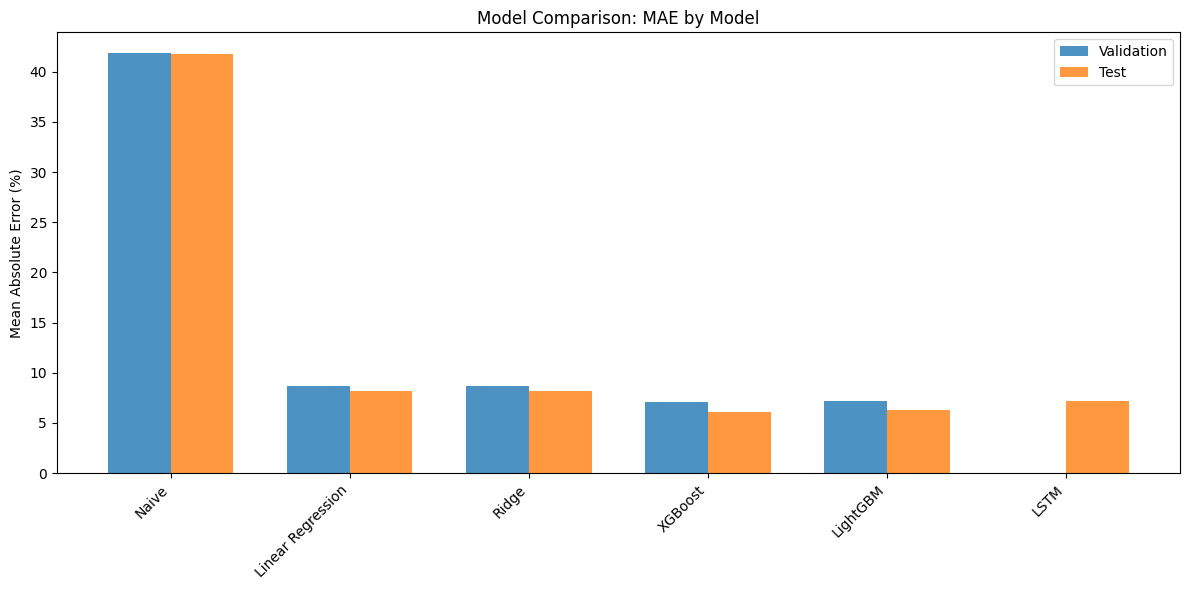

Plot saved to model_comparison.png


In [27]:
# Plot MAE comparison
plt.figure(figsize=(12, 6))
x     = np.arange(len(results_df))
width = 0.35

# fillna(0) for clean bar chart (NaN LSTM val becomes 0, visually clear)
val_mae  = results_df['Validation MAE'].fillna(0).tolist()
test_mae = results_df['Test MAE'].fillna(0).tolist()

plt.bar(x - width/2, val_mae,  width, label='Validation', alpha=0.8)
plt.bar(x + width/2, test_mae, width, label='Test',       alpha=0.8)

plt.ylabel('Mean Absolute Error (%)')
plt.title('Model Comparison: MAE by Model')
plt.xticks(x, results_df['Model'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to model_comparison.png")

## 📊 7b. Enhanced Model Comparison with CI Error Bars

Replaces the plain bar chart — error bars show 95% bootstrap CIs.

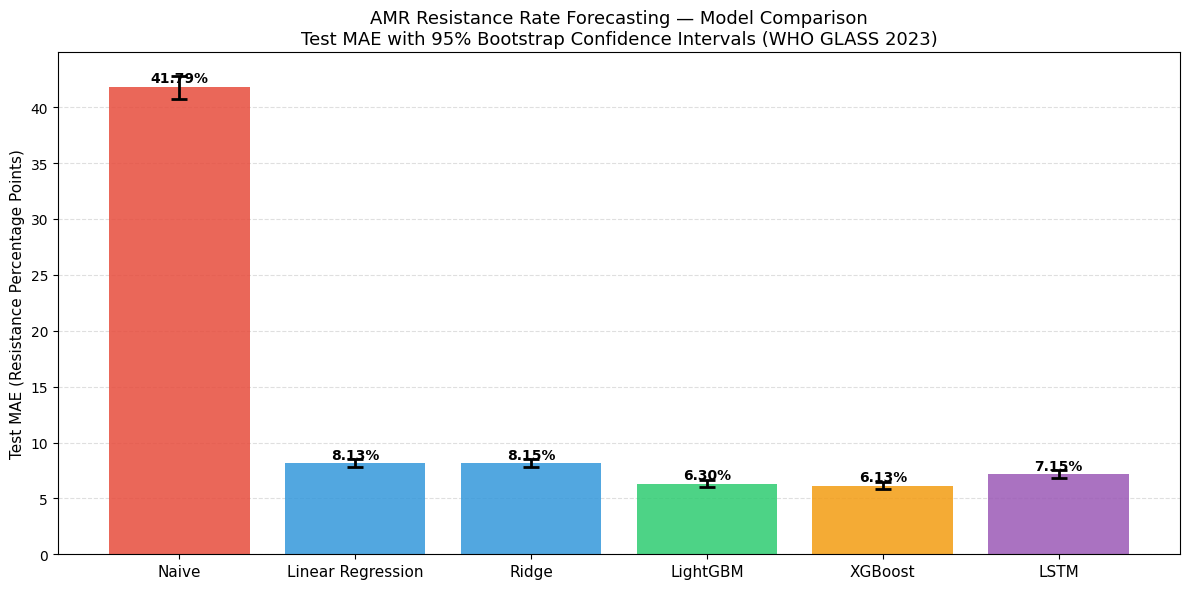

Saved: model_comparison_ci.png


In [28]:
# ─── Model comparison bar chart with 95% bootstrap CI error bars ────────
bar_order   = ['Naive', 'Linear Regression', 'Ridge', 'LightGBM', 'XGBoost', 'LSTM']
bar_colours = ['#e74c3c', '#3498db', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

mae_vals = [ci_results[m]['mae']                        for m in bar_order]
err_lo   = [ci_results[m]['mae'] - ci_results[m]['lo']  for m in bar_order]
err_hi   = [ci_results[m]['hi'] - ci_results[m]['mae']  for m in bar_order]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(bar_order))

bars = ax.bar(x, mae_vals, color=bar_colours, alpha=0.85,
              yerr=[err_lo, err_hi], error_kw=dict(lw=2, capsize=6, capthick=2))

for bar, v in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(err_hi) * 0.15,
            f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(bar_order, fontsize=11)
ax.set_ylabel('Test MAE (Resistance Percentage Points)', fontsize=11)
ax.set_title(
    'AMR Resistance Rate Forecasting — Model Comparison\n'
    'Test MAE with 95% Bootstrap Confidence Intervals (WHO GLASS 2023)',
    fontsize=13
)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('model_comparison_ci.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_ci.png')


## 📈 7c. Actual vs. Predicted — Three Models

Shows model calibration across the full 0–100% resistance range.

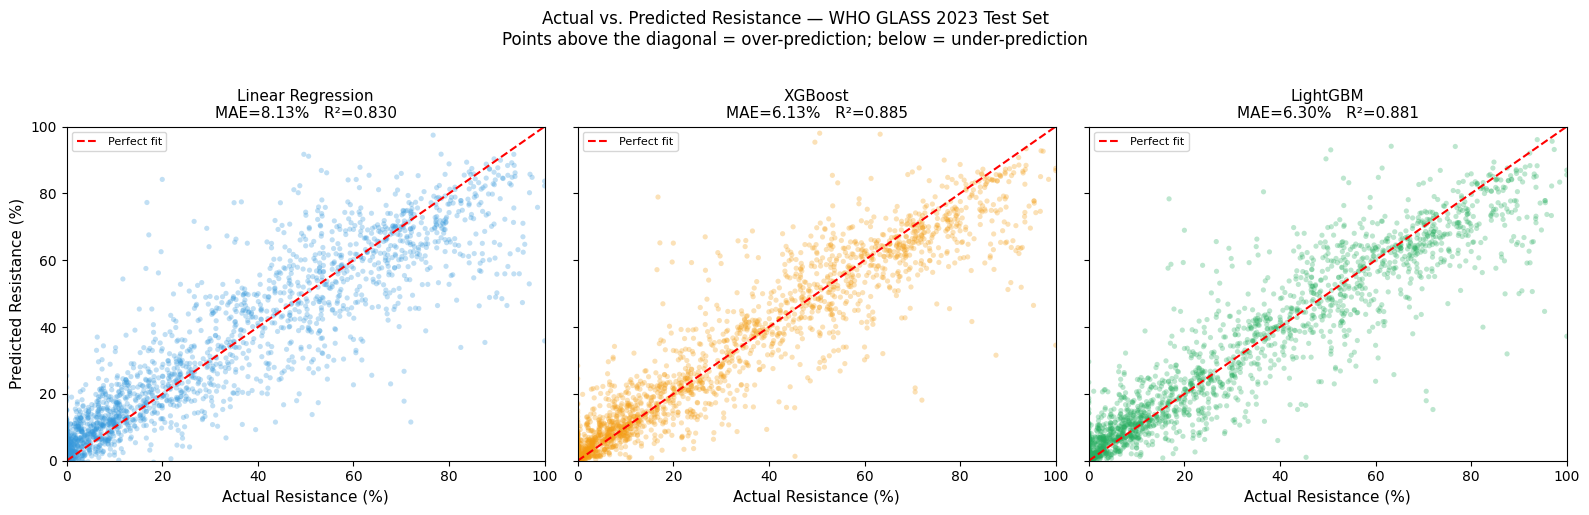

Saved: actual_vs_predicted.png


In [29]:
# --- Actual vs Predicted scatter for three models ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

pairs = [
    ('Linear Regression', y_test_pred_lr,   '#3498db'),
    ('XGBoost',           y_test_pred_xgb,  '#f39c12'),
    ('LightGBM',          y_test_pred_lgbm, '#27ae60'),
]

from sklearn.metrics import mean_absolute_error, r2_score

for ax, (name, preds, colour) in zip(axes, pairs):
    mae = mean_absolute_error(y_test, preds)
    r2  = r2_score(y_test, preds)
    ax.scatter(y_test, preds, alpha=0.30, s=14, color=colour, edgecolors='none')
    lim = [0, 100]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual Resistance (%)', fontsize=11)
    ax.set_title(f'{name}\nMAE={mae:.2f}%   R\u00b2={r2:.3f}', fontsize=11)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Predicted Resistance (%)', fontsize=11)
fig.suptitle(
    'Actual vs. Predicted Resistance — WHO GLASS 2023 Test Set\n'
    'Points above the diagonal = over-prediction; below = under-prediction',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: actual_vs_predicted.png')


## 📊 8. Error Analysis

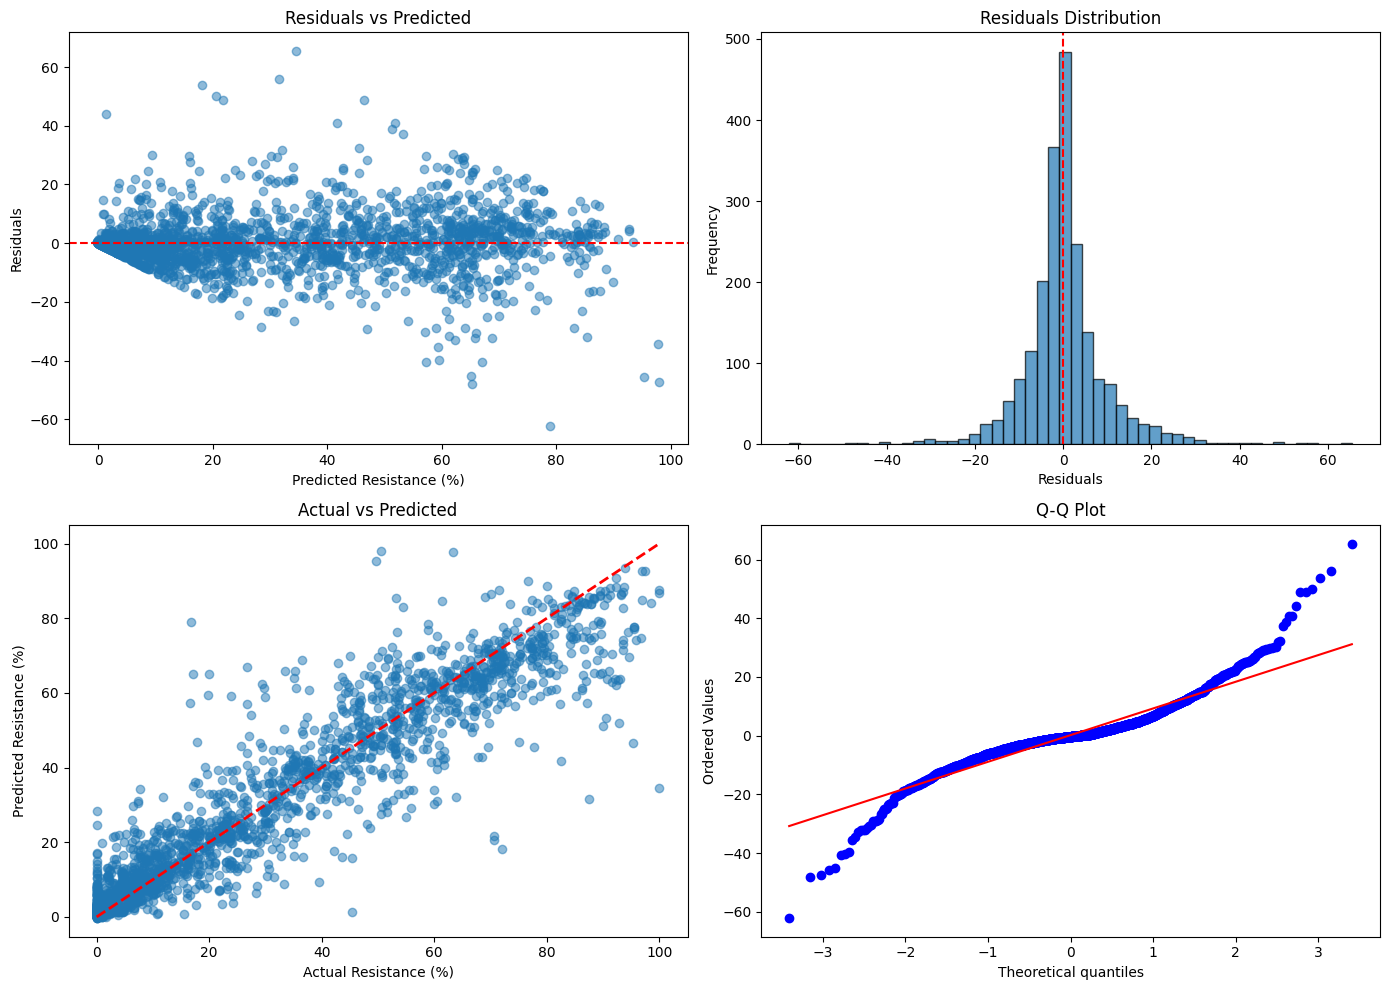

Error analysis plot saved to error_analysis.png


In [30]:
# Residual analysis for best model (assuming XGBoost is best)
best_model   = xgb_model
y_pred_best  = best_model.predict(X_test)
residuals    = y_test.values - y_pred_best

# Plot residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Predicted
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Resistance (%)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted')

# Residuals distribution
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Residuals Distribution')

# Actual vs Predicted
axes[1, 0].scatter(y_test, y_pred_best, alpha=0.5)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Resistance (%)')
axes[1, 0].set_ylabel('Predicted Resistance (%)')
axes[1, 0].set_title('Actual vs Predicted')

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Error analysis plot saved to error_analysis.png")


Mean Absolute Error by WHO Region:
                                 Error
Region                                
European Region               3.645535
Western Pacific Region        6.043242
Eastern Mediterranean Region  7.678855
African Region                8.125540
South-East Asia Region        8.607661


<Figure size 1000x500 with 0 Axes>

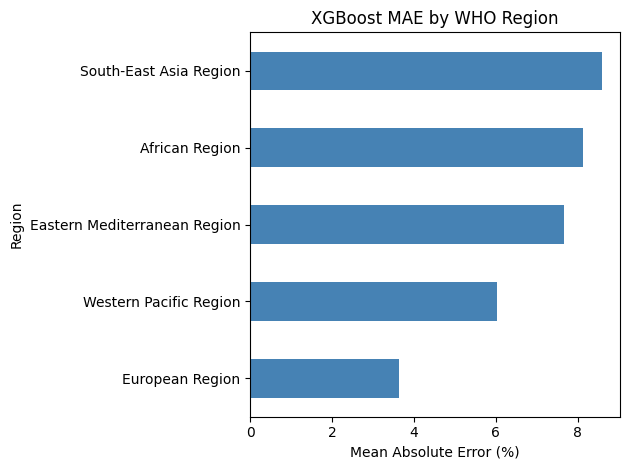

In [31]:
# Error by WHO region
#         use zip(transform(classes_), classes_) to build inverse mapping.
le_region      = label_encoders['WHORegionName']
region_decoder = dict(zip(
    le_region.transform(le_region.classes_),  # encoded integers
    le_region.classes_                         # original region strings
))

test_regions = test_df['WHORegionName'].map(region_decoder)

region_errors = pd.DataFrame({
    'Region': test_regions.values,
    'Error':  np.abs(residuals)
}).groupby('Region').mean().sort_values('Error')

print("\nMean Absolute Error by WHO Region:")
print(region_errors)

# Plot
plt.figure(figsize=(10, 5))
region_errors.plot(kind='barh', color='steelblue', legend=False)
plt.xlabel('Mean Absolute Error (%)')
plt.title('XGBoost MAE by WHO Region')
plt.tight_layout()
plt.savefig('mae_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

## 🔬 8b. Extended Epidemiological Analysis

Deeper insights into AMR patterns: resistance trends over time, error stratified by pathogen and resistance level, antibiotic consumption correlation, and the pathogen×antibiotic resistance heatmap.

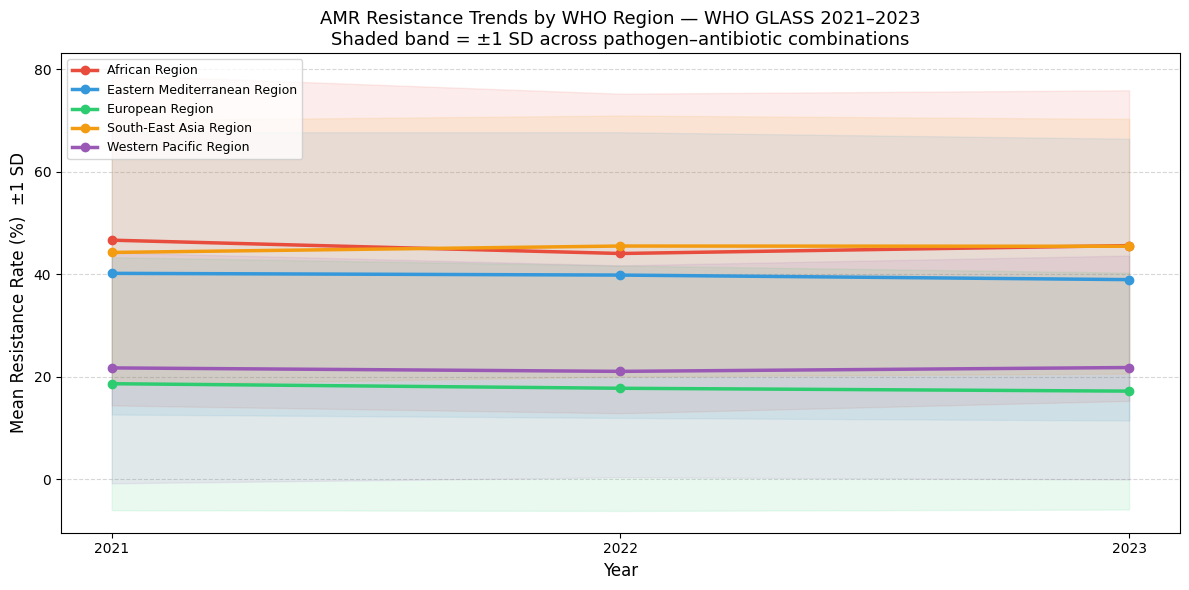

Saved: resistance_trends_by_region.png


In [32]:
# ─── 1. Resistance Trends Over Time by WHO Region ───────────────────────
region_year = (
    df.groupby(['WHORegionName', 'Year'])['ResistancePercentage']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

import matplotlib.cm as cm
regions  = region_year['WHORegionName'].unique()
palette  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, ax = plt.subplots(figsize=(12, 6))
for region, colour in zip(regions, palette):
    sub = region_year[region_year['WHORegionName'] == region].sort_values('Year')
    ax.plot(sub['Year'], sub['mean'], marker='o', lw=2.5,
            color=colour, label=region)
    ax.fill_between(
        sub['Year'],
        sub['mean'] - sub['std'],
        sub['mean'] + sub['std'],
        alpha=0.10, color=colour
    )

ax.set_xticks([2021, 2022, 2023])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean Resistance Rate (%)  ±1 SD', fontsize=12)
ax.set_title(
    'AMR Resistance Trends by WHO Region — WHO GLASS 2021–2023\n'
    'Shaded band = ±1 SD across pathogen–antibiotic combinations',
    fontsize=13
)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('resistance_trends_by_region.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: resistance_trends_by_region.png')


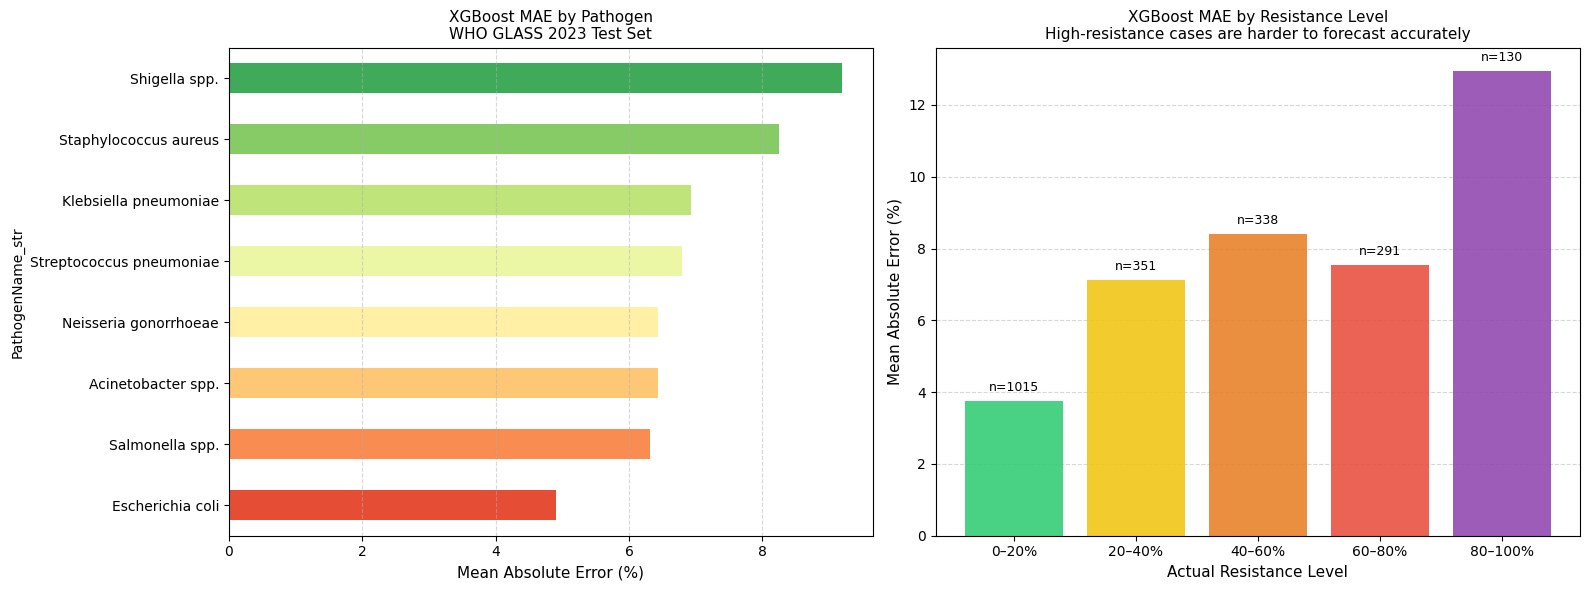

Saved: error_by_pathogen_and_level.png


In [33]:
# ─── 2. MAE by Pathogen + MAE by Resistance Level ──────────────────────
test_ext = test_df.copy()
test_ext['AbsError'] = np.abs(y_test.values - y_test_pred_xgb)

# Decode PathogenName (stored as label-encoded integers)
le_path = label_encoders['PathogenName']
path_decoder = dict(zip(le_path.transform(le_path.classes_), le_path.classes_))
test_ext['PathogenName_str'] = test_ext['PathogenName'].map(path_decoder)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: MAE by pathogen ---
pathogen_mae = (
    test_ext.groupby('PathogenName_str')['AbsError']
    .mean().sort_values(ascending=False)
)
colours = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(pathogen_mae)))
pathogen_mae.plot(kind='barh', ax=axes[0], color=colours)
axes[0].set_xlabel('Mean Absolute Error (%)', fontsize=11)
axes[0].set_title(
    'XGBoost MAE by Pathogen\n'
    'WHO GLASS 2023 Test Set',
    fontsize=11
)
axes[0].invert_yaxis()
axes[0].xaxis.grid(True, linestyle='--', alpha=0.5)

# --- Right: MAE by resistance level bin ---
test_ext['ResBin'] = pd.cut(
    test_ext['ResistancePercentage'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0–20%', '20–40%', '40–60%', '60–80%', '80–100%'],
    include_lowest=True
)
bin_mae   = test_ext.groupby('ResBin', observed=True)['AbsError'].mean()
bin_count = test_ext.groupby('ResBin', observed=True)['AbsError'].count()
bin_colours = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
bars = axes[1].bar(bin_mae.index, bin_mae.values, color=bin_colours, alpha=0.87)
for bar, n in zip(bars, bin_count.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
        f'n={n}', ha='center', va='bottom', fontsize=9
    )
axes[1].set_xlabel('Actual Resistance Level', fontsize=11)
axes[1].set_ylabel('Mean Absolute Error (%)', fontsize=11)
axes[1].set_title(
    'XGBoost MAE by Resistance Level\n'
    'High-resistance cases are harder to forecast accurately',
    fontsize=11
)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('error_by_pathogen_and_level.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: error_by_pathogen_and_level.png')


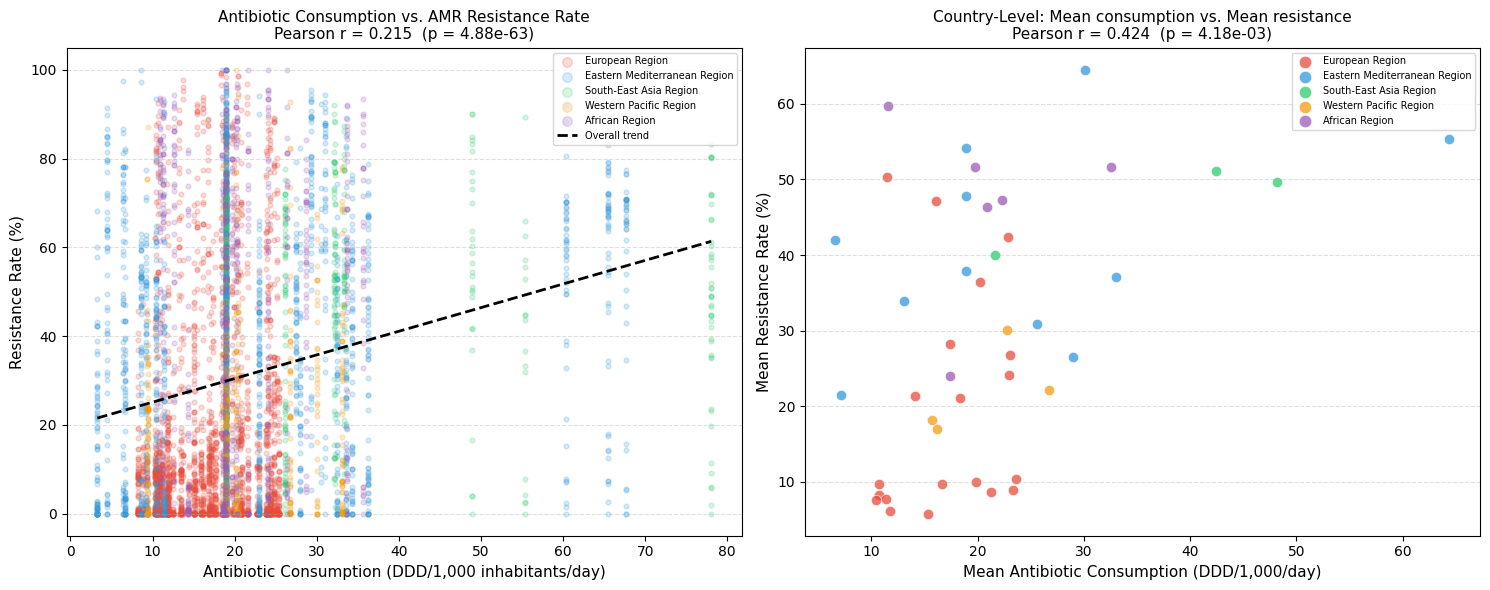

Saved: consumption_vs_resistance.png


In [34]:
# ─── 3. Antibiotic Consumption vs Resistance Correlation ────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

regions  = df['WHORegionName'].unique()
palette  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

# --- Left: scatter all observations ---
for region, colour in zip(regions, palette):
    sub = df[df['WHORegionName'] == region]
    axes[0].scatter(
        sub['Total_DID'], sub['ResistancePercentage'],
        alpha=0.20, s=12, color=colour, label=region
    )

# Overall trend line
from numpy.polynomial.polynomial import polyfit
_valid = df[['Total_DID', 'ResistancePercentage']].dropna()
_x = _valid['Total_DID'].values
_y = _valid['ResistancePercentage'].values
_c, _m = polyfit(_x, _y, 1)
_xr = np.linspace(_x.min(), _x.max(), 200)
axes[0].plot(_xr, _c + _m * _xr, 'k--', lw=2, label='Overall trend')

from scipy.stats import pearsonr
_r, _p = pearsonr(_x, _y)
axes[0].set_xlabel('Antibiotic Consumption (DDD/1,000 inhabitants/day)', fontsize=11)
axes[0].set_ylabel('Resistance Rate (%)', fontsize=11)
axes[0].set_title(
    f'Antibiotic Consumption vs. AMR Resistance Rate\n'
    f'Pearson r = {_r:.3f}  (p = {_p:.2e})',
    fontsize=11
)
axes[0].legend(fontsize=7, markerscale=2)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)

# --- Right: country-level mean DID vs mean resistance ---
country_agg = df.groupby('CountryTerritoryArea').agg(
    mean_resistance=('ResistancePercentage', 'mean'),
    mean_DID=('Total_DID', 'mean'),
    region=('WHORegionName', 'first')
).dropna()

for region, colour in zip(regions, palette):
    sub = country_agg[country_agg['region'] == region]
    axes[1].scatter(
        sub['mean_DID'], sub['mean_resistance'],
        alpha=0.75, s=55, color=colour, label=region, edgecolors='white', lw=0.5
    )

_ca_valid = country_agg.dropna()
_r2, _p2 = pearsonr(_ca_valid['mean_DID'], _ca_valid['mean_resistance'])
axes[1].set_xlabel('Mean Antibiotic Consumption (DDD/1,000/day)', fontsize=11)
axes[1].set_ylabel('Mean Resistance Rate (%)', fontsize=11)
axes[1].set_title(
    f'Country-Level: Mean consumption vs. Mean resistance\n'
    f'Pearson r = {_r2:.3f}  (p = {_p2:.2e})',
    fontsize=11
)
axes[1].legend(fontsize=7, markerscale=1.2)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('consumption_vs_resistance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: consumption_vs_resistance.png')


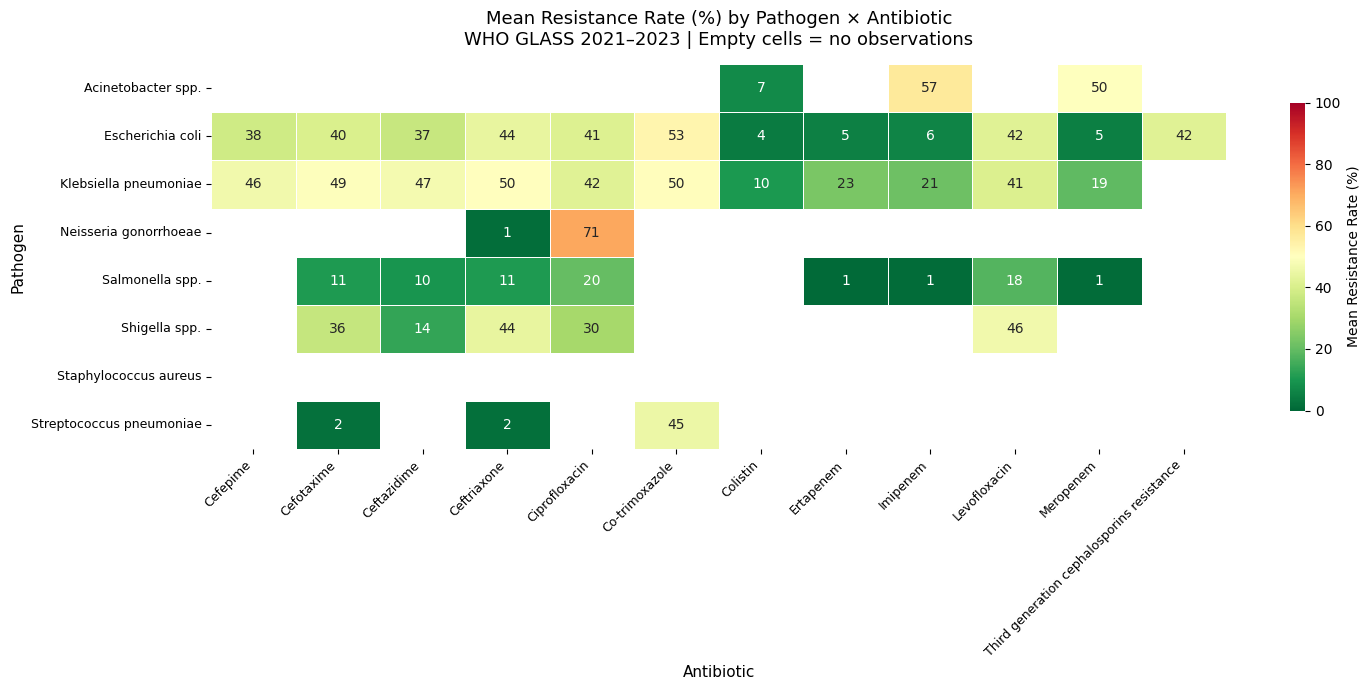

Saved: resistance_heatmap.png

Top 10 highest-resistance pathogen-antibiotic combinations:
PathogenName           AntibioticName
Neisseria gonorrhoeae  Ciprofloxacin     71.061837
Escherichia coli       Ampicillin        69.940712
Acinetobacter spp.     Imipenem          56.723551
                       Doripenem         54.810903
Escherichia coli       Co-trimoxazole    53.249326
Klebsiella pneumoniae  Co-trimoxazole    50.481226
                       Ceftriaxone       50.170427
Acinetobacter spp.     Meropenem         49.878155
Klebsiella pneumoniae  Cefotaxime        49.276744
                       Ceftazidime       47.059880


In [35]:
# ─── 4. Resistance Heatmap — Pathogen × Antibiotic ──────────────────────
pivot = (
    df.groupby(['PathogenName', 'AntibioticName'])['ResistancePercentage']
    .mean()
    .unstack()
)

# Select top pathogens and antibiotics by observation count
top_pathogens  = df['PathogenName'].value_counts().head(10).index
top_antibiotics = df['AntibioticName'].value_counts().head(12).index
pivot_sub = pivot.loc[
    pivot.index.intersection(top_pathogens),
    pivot.columns.intersection(top_antibiotics)
]

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    pivot_sub,
    annot=True, fmt='.0f',
    cmap='RdYlGn_r',
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Mean Resistance Rate (%)', 'shrink': 0.8}
)
ax.set_title(
    'Mean Resistance Rate (%) by Pathogen \u00d7 Antibiotic\n'
    'WHO GLASS 2021\u20132023 | Empty cells = no observations',
    fontsize=13, pad=14
)
ax.set_xlabel('Antibiotic', fontsize=11)
ax.set_ylabel('Pathogen', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('resistance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: resistance_heatmap.png')

# Print highest-resistance combinations for the paper
top_combos = (
    df.groupby(['PathogenName', 'AntibioticName'])['ResistancePercentage']
    .mean().sort_values(ascending=False).head(10)
)
print('\nTop 10 highest-resistance pathogen-antibiotic combinations:')
print(top_combos.to_string())


In [36]:
# ─── 5. Regional Analysis with Country Counts (paper Table 4) ──────────
# Decode WHORegionName (label-encoded integers → strings)
le_region      = label_encoders['WHORegionName']
region_decoder = dict(zip(
    le_region.transform(le_region.classes_),
    le_region.classes_
))
test_regions_str = test_df['WHORegionName'].map(region_decoder)

# Country counts AFTER decoding (fixes NaN bug in coverage scatter)
_region_counts = (
    pd.DataFrame({'Region':  test_regions_str.values,
                  'Country': test_df['CountryTerritoryArea'].values})
    .groupby('Region')['Country'].nunique()
)

# Build region_full with MAE, RMSE, N_obs, N_countries
region_full = pd.DataFrame({
    'Region':   test_regions_str.values,
    'AbsError': np.abs(y_test.values - y_test_pred_xgb)
}).groupby('Region').agg(
    MAE=('AbsError', 'mean'),
    RMSE=('AbsError', lambda x: np.sqrt(np.mean(x**2))),
    N_obs=('AbsError', 'count')
).reset_index()

region_full['N_countries'] = region_full['Region'].map(_region_counts)
region_full = region_full.sort_values('MAE')

print('=== Extended Regional Error Table (for paper Table 4) ===')
print(region_full.to_string(index=False))
region_full.to_csv('regional_mae_extended.csv', index=False)
print('\n✅ Saved: regional_mae_extended.csv')


=== Extended Regional Error Table (for paper Table 4) ===
                      Region      MAE      RMSE  N_obs  N_countries
             European Region 3.645535  6.770914    809           20
      Western Pacific Region 6.043242  9.437361    181            4
Eastern Mediterranean Region 7.678855 11.144373    709           11
              African Region 8.125540 10.771041    265            6
      South-East Asia Region 8.607661 11.857490    161            3

✅ Saved: regional_mae_extended.csv


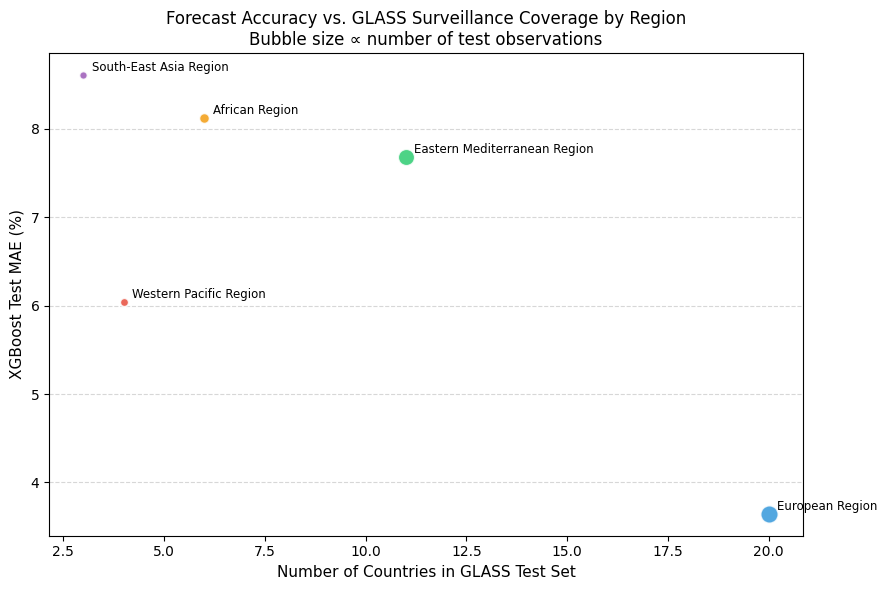

Saved: regional_mae_vs_coverage.png


In [37]:
# ─── 6. Regional MAE vs. GLASS participation scatter ───────────────────
# Shows that forecast accuracy tracks surveillance coverage
fig, ax = plt.subplots(figsize=(9, 6))

scatter_colours = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
for (_, row), colour in zip(region_full.iterrows(), scatter_colours):
    ax.scatter(row['N_countries'], row['MAE'],
               s=row['N_obs'] / 5, color=colour, alpha=0.85,
               edgecolors='white', lw=1.2)
    ax.annotate(
        row['Region'],
        xy=(row['N_countries'], row['MAE']),
        xytext=(6, 3), textcoords='offset points',
        fontsize=8.5
    )

ax.set_xlabel('Number of Countries in GLASS Test Set', fontsize=11)
ax.set_ylabel('XGBoost Test MAE (%)', fontsize=11)
ax.set_title(
    'Forecast Accuracy vs. GLASS Surveillance Coverage by Region\n'
    'Bubble size \u221d number of test observations',
    fontsize=12
)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('regional_mae_vs_coverage.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: regional_mae_vs_coverage.png')


## 💾 9. Save Models

In [38]:
import joblib, os

os.makedirs('models', exist_ok=True)

# Save traditional models
joblib.dump(lr_model,    'models/lr_model.pkl')
joblib.dump(ridge_model, 'models/ridge_model.pkl')
joblib.dump(xgb_model,   'models/xgb_model.pkl')
joblib.dump(lgbm_model,  'models/lgbm_model.pkl')

# Save preprocessing objects
joblib.dump(label_encoders, 'models/label_encoders.pkl')
joblib.dump(scaler,         'models/scaler.pkl')

# Save feature list
with open('models/features.txt', 'w') as f:
    f.write('\n'.join(FEATURES_ENCODED))

# Save LSTM model
torch.save(lstm_model.state_dict(), 'models/lstm_model.pth')

print("✅ All models and preprocessing objects saved to 'models/' directory!")

✅ All models and preprocessing objects saved to 'models/' directory!


## ✅ 10. Summary & Next Steps

In [39]:
# Save XGBoost feature importance to CSV
xgb_importance.to_csv('xgb_feature_importance.csv', index=False)
print(f'Saved: xgb_feature_importance.csv ({len(xgb_importance)} features)')
print(xgb_importance.to_string(index=False))


Saved: xgb_feature_importance.csv (13 features)
                  Feature  Importance
          Resistance_lag1    0.505483
  CountryTerritoryArea_te    0.090224
        AntibioticName_te    0.067378
             PathogenName    0.059761
            InfectionType    0.052838
              IncomeGroup    0.050563
          AntibioticClass    0.043583
            WHORegionName    0.041319
                Total_DID    0.026775
                 DID_lag1    0.021119
Country_Observation_Count    0.020924
     High_Quality_Country    0.020034
                     Year    0.000000


In [40]:
print("\n" + "="*70)
print("TRAINING PIPELINE COMPLETE")
print("="*70)

print("\n📊 Results Summary:")
print(results_df.to_string(index=False))

print("\n✅ Completed:")
print("  - Data loading and inspection")
print("  - Leakage prevention (Resistance_YoY_change excluded)")
print("  - Categorical encoding (target + label encoding, train-only)")
print("  - Step 1: temporal split (2021 / 2022 / 2023) for hyperparameter selection")
print("  - Step 2: retrain on 2021+2022 combined, evaluate on 2023")
print("  - Feature scaling (train fit, val/test transform)")
print("  - Baseline models (Naive, Linear, Ridge)")
print("  - Gradient boosting models (XGBoost, LightGBM)")
print("  - Deep learning model (LSTM with tabular reshape, same splits as XGBoost)")
print("  - Model comparison and visualization")
print("  - Error analysis by WHO region")
print("  - Models and artifacts saved")

print("\n📁 Generated Files:")
print("  - model_comparison_results.csv")
print("  - model_comparison.png")
print("  - error_analysis.png")
print("  - mae_by_region.png")
print("  - xgb_feature_importance.png")
print("  - models/ (directory with all saved models)")

print("\n🚀 Next Steps:")
print("  1. Hyperparameter tuning for best model (XGBoost/LightGBM likely winners)")
print("  2. BiLSTM and TFT models (GPU: RTX 5060)")
print("  3. Ablation study: model with/without consumption features")
print("  4. Regional breakdown analysis (AFRO, EMRO, EURO, SEARO, WPRO)")
print("  5. RAG pipeline for policy Q&A")

print("\n" + "="*70)


TRAINING PIPELINE COMPLETE

📊 Results Summary:
            Model  Validation MAE  Test MAE  Validation RMSE  Test RMSE  Validation R2  Test R2
            Naive       41.827262 41.793204        48.149718  48.026575            NaN      NaN
Linear Regression        8.635278  8.134610        12.923747  11.671302       0.796244 0.829525
            Ridge        8.639178  8.145004        12.898719  11.670624       0.797033 0.829545
          XGBoost        7.092339  6.130106        11.623738   9.570685       0.835174 0.885367
         LightGBM        7.226457  6.304240        11.810058   9.757893       0.829848 0.880839
             LSTM             NaN  7.148021              NaN  10.836820            NaN 0.853031

✅ Completed:
  - Data loading and inspection
  - Leakage prevention (Resistance_YoY_change excluded)
  - Categorical encoding (target + label encoding, train-only)
  - Step 1: temporal split (2021 / 2022 / 2023) for hyperparameter selection
  - Step 2: retrain on 2021+2022 combi